In [1]:
#load & Inspect the data
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('retail_sales_data.csv')

# Display the first few rows of the dataset
print(data.head())

# Check for missing values
print(data.isnull().sum())


   Order_ID  Order_Date Customer       City     Category Product  Quantity  \
0      1001  2024-02-01    Dipam  Bangalore  Electronics  Laptop       1.0   
1      1002  2024-02-01      Raj     Mumbai  Electronics   Phone       2.0   
2      1003  2024-02-02    Anita      Delhi    Furniture   Chair       4.0   
3      1004  2024-02-02    Karan  Bangalore  Electronics  Tablet       1.0   
4      1005  2024-02-03    Meena     Mumbai    Furniture   Table       1.0   

     Price Payment_Mode  
0  65000.0          UPI  
1  22000.0  Credit Card  
2   3000.0         Cash  
3  28000.0          UPI  
4  15000.0  Credit Card  
Order_ID        0
Order_Date      0
Customer        0
City            0
Category        0
Product         0
Quantity        1
Price           1
Payment_Mode    0
dtype: int64


In [3]:
# Fill quantity missing values by median
data['Quantity'] = data['Quantity'].fillna(data['Quantity'].median())

# Fill price missing values by mean
data['Price'] = data['Price'].fillna(data['Price'].mean())

# Verify that there are no more missing values
print(data.isnull().sum())

#convert order_date to datetime
data['Order_Date'] = pd.to_datetime(data['Order_Date'], errors='coerce')

Order_ID        0
Order_Date      0
Customer        0
City            0
Category        0
Product         0
Quantity        0
Price           0
Payment_Mode    0
dtype: int64


In [4]:
#Feature Engineering
data['Total_Sales'] = data['Quantity'] * data['Price']

print(data.head())


   Order_ID Order_Date Customer       City     Category Product  Quantity  \
0      1001 2024-02-01    Dipam  Bangalore  Electronics  Laptop       1.0   
1      1002 2024-02-01      Raj     Mumbai  Electronics   Phone       2.0   
2      1003 2024-02-02    Anita      Delhi    Furniture   Chair       4.0   
3      1004 2024-02-02    Karan  Bangalore  Electronics  Tablet       1.0   
4      1005 2024-02-03    Meena     Mumbai    Furniture   Table       1.0   

     Price Payment_Mode  Total_Sales  
0  65000.0          UPI      65000.0  
1  22000.0  Credit Card      44000.0  
2   3000.0         Cash      12000.0  
3  28000.0          UPI      28000.0  
4  15000.0  Credit Card      15000.0  


In [11]:
# Business Analysis

# Total Revenue
total_revenue = data['Total_Sales'].sum()
print(f'Total Revenue: ${total_revenue:.2f}')

# Revenue by City
revenue_by_city = data.groupby('City')['Total_Sales'].sum().sort_values(ascending=False).reset_index()
print(revenue_by_city)

# Revenue by Product Category
revenue_by_category = data.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False).reset_index()
print(revenue_by_category)

# Revenue by payment method
revenue_by_payment = data.groupby('Payment_Mode')['Total_Sales'].sum().sort_values(ascending=False).reset_index()
print(revenue_by_payment)

# Top 3 products by revenue
top_3_products = data.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).head(3)
print(top_3_products)

# City with highest revenue
top_city = revenue_by_city.loc[revenue_by_city["Total_Sales"].idxmax(), "City"]
print(f'City with highest revenue: {top_city}')

Total Revenue: $459090.91
        City    Total_Sales
0  Bangalore  192090.909091
1     Mumbai  152000.000000
2      Delhi  115000.000000
      Category    Total_Sales
0  Electronics  318000.000000
1    Furniture  141090.909091
  Payment_Mode    Total_Sales
0          UPI  252000.000000
1         Cash  126090.909091
2  Credit Card   81000.000000
Product
Phone     132000.000000
Laptop    130000.000000
Chair      71090.909091
Name: Total_Sales, dtype: float64
City with highest revenue: Bangalore


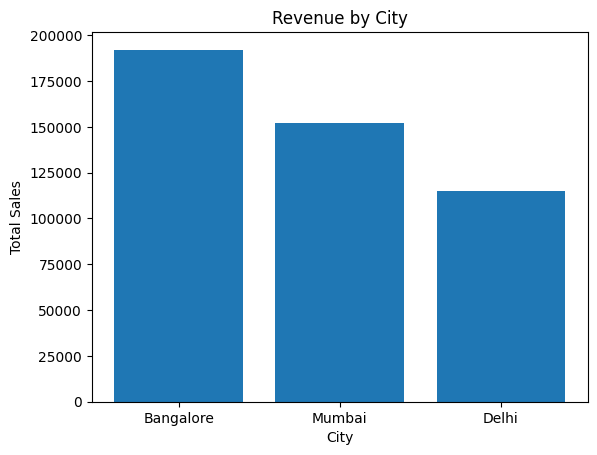

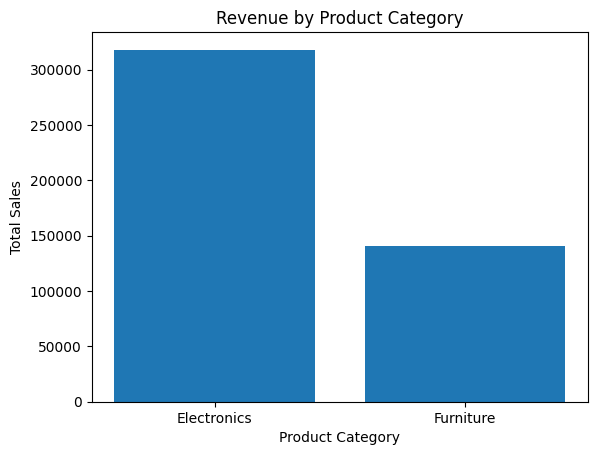

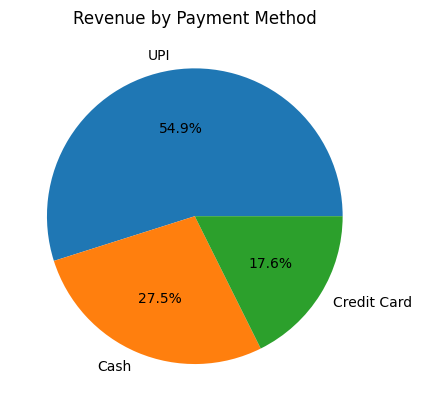

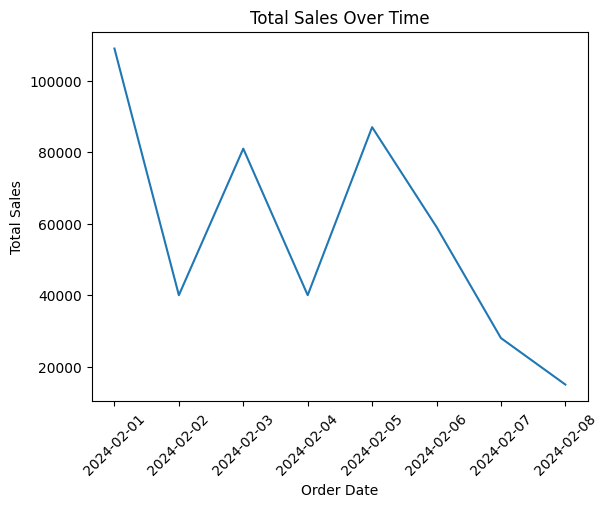

In [ ]:
# Visualize

# Revenue by City
plt.figure ()
plt.bar(revenue_by_city['City'], revenue_by_city['Total_Sales'])
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.show()

# Revenue by Product Category
plt.figure ()
plt.bar(revenue_by_category['Category'], revenue_by_category['Total_Sales'])
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()

# Revenue by Payment Method
plt.figure ()
plt.pie(revenue_by_payment['Total_Sales'], labels=revenue_by_payment['Payment_Mode'], autopct='%1.1f%%')
plt.title('Revenue by Payment Method')
plt.show()

# Line sales trend over time
plt.figure ()
total_sales_over_time = data.groupby('Order_Date')['Total_Sales'].sum().reset_index()
plt.plot(total_sales_over_time['Order_Date'], total_sales_over_time['Total_Sales'])
plt.title('Total Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


#📊 Business Insights

#1️⃣ Bangalore generates the highest revenue, indicating strong market demand in that region.

#2️⃣ Electronics category contributes the majority of revenue, making it the core business driver.

#3️⃣ UPI is the dominant payment method, suggesting customers prefer digital payments.

#4️⃣ Sales show strong performance in early February, with slight fluctuations later — no clear downward trend but moderate daily variation.
